# EDA_momento1CC – Producción de frutales en el Valle del Cauca

- **Fuente:** datos.gov.co (Agricultura y Desarrollo Rural)
- **Enlace:** https://www.datos.gov.co/Agricultura-y-Desarrollo-Rural/Producci-n-de-frutales-en-el-Valle-del-Cauca/8xap-gecf
- **Fecha de descarga:** 28 de septiembre de 2026
- **Qué es una fila:** un municipio, en un año, para un cultivo.
- **Periodo:** 2000 a 2022.

## Preguntas de investigación
1. ¿Ha crecido la producción total de frutales entre 2000 y 2022?
2. ¿Qué cultivos y qué subregiones concentran la mayor producción?
3. ¿Cambia el comportamiento según la subregión o el ciclo (anual o semestral)?
4. ¿Qué municipios producen más, y la producción está concentrada en pocos municipios?
5. ¿Qué cultivos han ganado o perdido más producción entre 2000-2004 y 2018-2022?

In [1]:
%pip install -q pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Se cargan las herramientas para graficar

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargar y mirar los datos del CSV

In [3]:
from pathlib import Path

opciones = [
    Path("datos/frutales.csv"),
    Path("frutales.csv"),
    Path("datos/Producción_de_frutales_en_el_Valle_del_Cauca_20260928.csv"),
    Path("Producción_de_frutales_en_el_Valle_del_Cauca_20260928.csv"),
]
ruta = next((p for p in opciones if p.exists()), None)
if ruta is None:
    raise FileNotFoundError("No encuentro el CSV. Ponlo en la carpeta 'datos' al lado de este cuaderno y llámalo frutales.csv")

df = pd.read_csv(ruta)
print("Archivo cargado:", ruta)
print(df.shape)
df.head()

Archivo cargado: frutales.csv
(9992, 8)


,año,Id_municipio,Municipio,Subregion,Id_cultivo,Cultivo,Ciclo,Produccion_toneladas
0,2022,76233,Dagua,Sur,2045801,Plátano,Anual,14.088
1,2022,76100,Bolivar,Norte,2045801,Plátano,Anual,6.578
2,2022,76243,El Aguila,Norte,2045801,Plátano,Anual,26.000
3,2022,76001,Cali,Sur,2045801,Plátano,Anual,186
4,2022,76275,Florida,Sur,2045801,Plátano,Anual,"2.124,4"


Se muestra el nombre para cada columna, cuántos datos tiene y de qué tipo es si número o texto.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   año                   9992 non-null   int64
 1   Id_municipio          9992 non-null   int64
 2   Municipio             9992 non-null   str  
 3   Subregion             9992 non-null   str  
 4   Id_cultivo            9992 non-null   int64
 5   Cultivo               9992 non-null   str  
 6   Ciclo                 9992 non-null   str  
 7   Produccion_toneladas  9992 non-null   str  
dtypes: int64(3), str(5)
memory usage: 624.6 KB


Con df.info() se identifican que existen 9.992 filas y 8 columnas, sin celdas vacías. La columna `Produccion_toneladas` aparece como texto (`object`) porque viene con puntos y comas.

Apartir de este pundo iniciamos la limpieza de los datos.

Se convierten las toneladas de texto a número:
- `df["Produccion_toneladas"]`: toma la columna original (texto).
- `.str.replace(".", "", ...)`: quita los puntos (los miles).
- `.str.replace(",", ".", ...)`: cambia la coma decimal por punto, que es como el programa entiende los decimales.
- `.astype(float)`: convierte el resultado a número.
- Todo se guarda en una **columna nueva** llamada `produccion`. La original queda intacta por si hay que revisarla.
- La última línea muestra las dos columnas lado a lado para comprobar que la conversión salió bien.

In [5]:
df["produccion"] = (
    df["Produccion_toneladas"]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
df[["Produccion_toneladas", "produccion"]].head(10)

,Produccion_toneladas,produccion
0,14.088,14088.0
1,6.578,6578.0
2,26.000,26000.0
3,186,186.0
4,"2.124,4",2124.4
5,416,416.0
6,1.110,1110.0
7,12.000,12000.0
8,1.957,1957.0
9,1.176,1176.0


**Por qué se hizo:** sin este paso `26.000` se leería como 26, y todas las sumas y promedios saldrían mal.

Cambiar el nombre de `año` por `anio` para evitar errores.

In [6]:
df = df.rename(columns={"año": "anio"})
df.columns.tolist()

['anio',
 'Id_municipio',
 'Municipio',
 'Subregion',
 'Id_cultivo',
 'Cultivo',
 'Ciclo',
 'Produccion_toneladas',
 'produccion']

Eliminar las filas repetidas que sean identicas, posteriormente mostrar cuantas eran y cuantas quedaron.

In [7]:
print("Filas exactamente repetidas:", df.duplicated().sum())
filas_antes = df.shape[0]
df = df.drop_duplicates()
print("Filas antes:", filas_antes, "| Filas ahora:", df.shape[0])

Filas exactamente repetidas: 39
Filas antes: 9992 | Filas ahora: 9953


Identificar cuantas filas poseen un valor de 0, lo cual indica que la producción es exactamente 0.

In [8]:
print("Filas con producción 0:", (df["produccion"] == 0).sum())

Filas con producción 0: 202


Revisar las que celdas estan vacías y la categoría a la que corresponde.

- `df.isna().sum()`: cuenta las celdas vacías de cada columna.
- `df["Ciclo"].value_counts()`: cuenta cuántas filas hay de cada ciclo (Anual, Semestre 1, Semestre 2).
- `df["Subregion"].value_counts()`: cuenta cuántas filas hay de cada subregión. Sirve para detectar grupos muy pequeños.

In [9]:
print(df.isna().sum())
print()
print(df["Ciclo"].value_counts())
print()
print(df["Subregion"].value_counts())

anio                    0
Id_municipio            0
Municipio               0
Subregion               0
Id_cultivo              0
Cultivo                 0
Ciclo                   0
Produccion_toneladas    0
produccion              0
dtype: int64

Ciclo
Anual         9617
Semestre 1     171
Semestre 2     165
Name: count, dtype: int64

Subregion
Norte       3655
Centro      3301
Sur         2833
Pacifico     164
Name: count, dtype: int64


Ajustar las escalas ya que algunos datos son muy grande y la mayoría son pequeños entonces si posteriormente se grafica no se visualizarían los datos mas pequeños.

In [10]:
df["log_prod"] = np.log10(df["produccion"] + 1)

Generar una impresión de la limpieza realizada, en la cual ya tenemos identificado que cierto datos deben ser texto y otros números.

In [11]:
print(df.dtypes)
print()
print("Tamaño final:", df.shape)

anio                      int64
Id_municipio              int64
Municipio                   str
Subregion                   str
Id_cultivo                int64
Cultivo                     str
Ciclo                       str
Produccion_toneladas        str
produccion              float64
log_prod                float64
dtype: object

Tamaño final: (9953, 10)


**Resumen de la limpieza**
- Toneladas convertidas de texto a número.
- Columna `año` renombrada a `anio`.
- 39 filas repetidas eliminadas.
- 202 ceros conservados y anotados.
- Sin celdas vacías.
- Variable `log_prod` creada para graficar.

## (Univariado)

Determinación de la cantidad de datos, el promedio (mean), la desviación (std), el mínimo, los cuartiles (25 %, 50 %, 75 %) y el máximo y el 50 % es la **mediana**

In [12]:
df["produccion"].describe()

count      9953.000000
mean       1645.043212
std        5290.149119
min           0.000000
25%          60.000000
50%         200.000000
75%         966.000000
max      105000.000000
Name: produccion, dtype: float64

Analizamos estos datos y evidenciamos que el conveniente a tener en cuenta es la mediana ya que la media es muy alto ya que se esta viendo afectado por pocos casos enormes, la mediana si nos muestra el común de los casos.

Generación de un histograma.

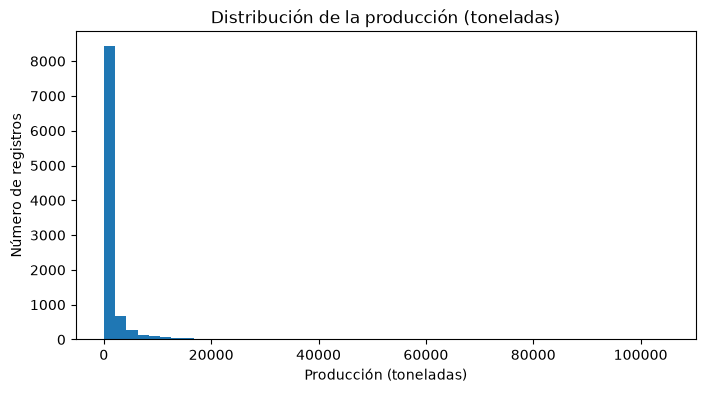

In [13]:
fig, eje = plt.subplots(figsize=(8, 4))
eje.hist(df["produccion"], bins=50)
eje.set_title("Distribución de la producción (toneladas)")
eje.set_xlabel("Producción (toneladas)")
eje.set_ylabel("Número de registros")
plt.show()

Se evidencia que predominan los registros de menores toneladas produccidas, ya que la mayoría son producciones pequeñas; Sin embargo, el grafico tiende ligeramente a la derecha por que tambien existen producciones grandes (poscos casos, pero existen).

El grafico inferior es el mismo histograma, sin embargo este es generado con la reducción de la escal que se realizo con anterioridad para facilitar la visualización de los datos mas grandes.

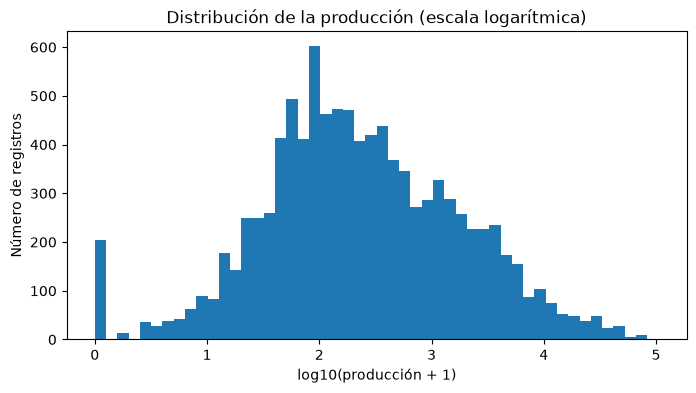

In [14]:
fig, eje = plt.subplots(figsize=(8, 4))
eje.hist(df["log_prod"], bins=50)
eje.set_title("Distribución de la producción (escala logarítmica)")
eje.set_xlabel("log10(producción + 1)")
eje.set_ylabel("Número de registros")
plt.show()

### 4.3 Boxplot de la producción

Se genera un grafico Boxplot de la producción, en este podemos apreciar los datos que van del 25 % al 75 %, La línea del medio es la mediana. Los puntos sueltos son casos extremos (outliers).

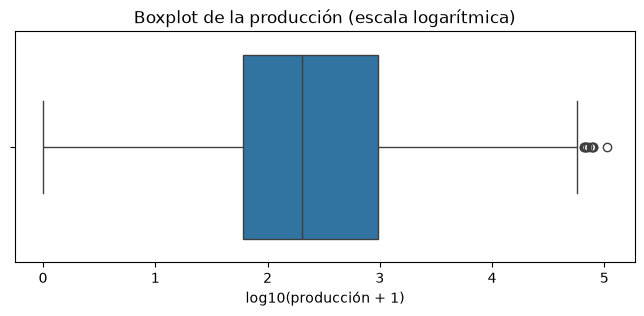

In [15]:
fig, eje = plt.subplots(figsize=(8, 3))
sns.boxplot(data=df, x="log_prod", ax=eje)
eje.set_title("Boxplot de la producción (escala logarítmica)")
eje.set_xlabel("log10(producción + 1)")
plt.show()

Se grafican el número de registros para las categorias o subregiones y en ciclos. (2 Graficas)

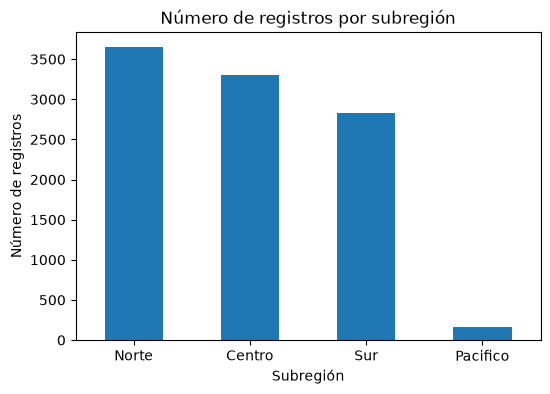

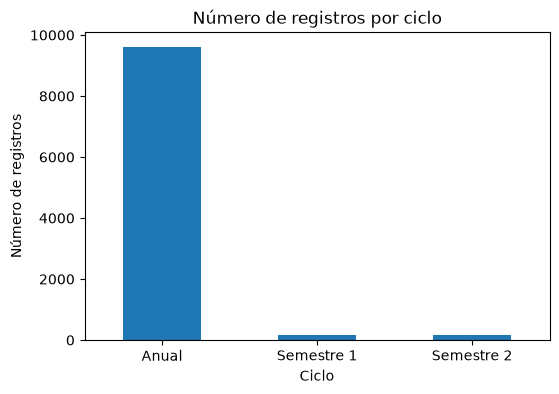

In [16]:
fig, eje = plt.subplots(figsize=(6, 4))
df["Subregion"].value_counts().plot(kind="bar", ax=eje)
eje.set_title("Número de registros por subregión")
eje.set_xlabel("Subregión")
eje.set_ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()

fig, eje = plt.subplots(figsize=(6, 4))
df["Ciclo"].value_counts().plot(kind="bar", ax=eje)
eje.set_title("Número de registros por ciclo")
eje.set_xlabel("Ciclo")
eje.set_ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()

El Pacífico tiene muy pocos registros, y todos son de ciclo Anual. casi todos son "Anual", y Semestre 1 y Semestre 2 refleja apenas algunos datos. Esto sugiere que el dataset es sobre todo de cultivos con reporte anual (por ejemplo, frutales permanentes como aguacate, mango o cítricos), mientras que los cultivos semestrales están casi ausentes. Para análisis por ciclo, esas dos categorías tienen tan pocos datos que cualquier conclusión sería frágil.

Graficar en barras los registros por años de menor a mayor.

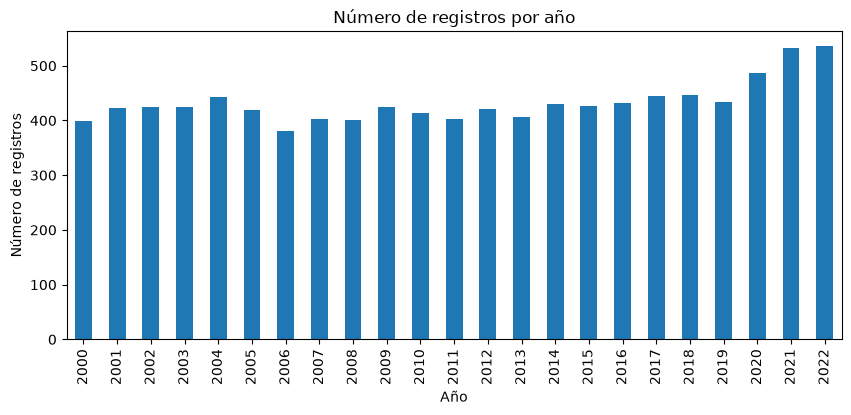

In [17]:
fig, eje = plt.subplots(figsize=(10, 4))
df["anio"].value_counts().sort_index().plot(kind="bar", ax=eje)
eje.set_title("Número de registros por año")
eje.set_xlabel("Año")
eje.set_ylabel("Número de registros")
plt.show()

Los últimos años (2020 a 2022) tienen más registros que los primeros.

## (Bivariado)


Graficar los datos del mismo año, teniendo en cuenta la producción, cuantos cultivos distintos habían.

In [18]:
anual = df.groupby("anio").agg(
    total=("produccion", "sum"),
    n_cultivos=("Cultivo", "nunique"),
    n_registros=("produccion", "size"),
).reset_index()
anual.head()

,anio,total,n_cultivos,n_registros
0,2000,410278.2262,30,399
1,2001,404114.9500,30,423
2,2002,454098.1000,30,424
3,2003,494228.7000,30,425
4,2004,487069.4000,30,443


Generación de grafico de lineas de la producción total de cada año. (La producción total en toneladas ah incrementado entre el 2020 y el 2022).

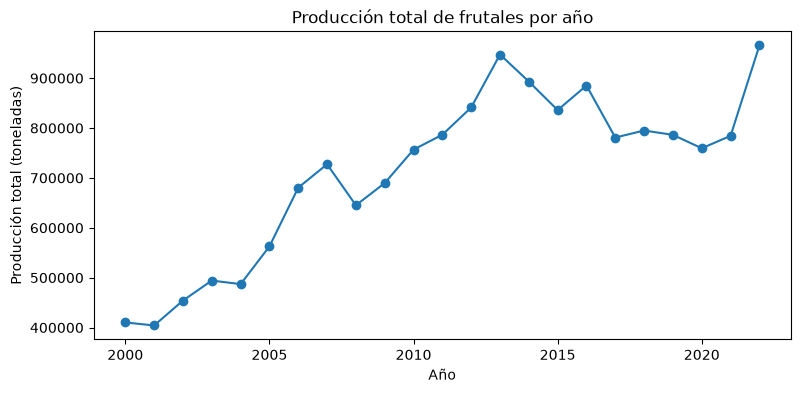

In [19]:
fig, eje = plt.subplots(figsize=(9, 4))
eje.plot(anual["anio"], anual["total"], marker="o")
eje.set_title("Producción total de frutales por año")
eje.set_xlabel("Año")
eje.set_ylabel("Producción total (toneladas)")
plt.show()

El mismo grafico anterior sin embargo los puntos por año no se encuentra unidos por una linea de tendencia.

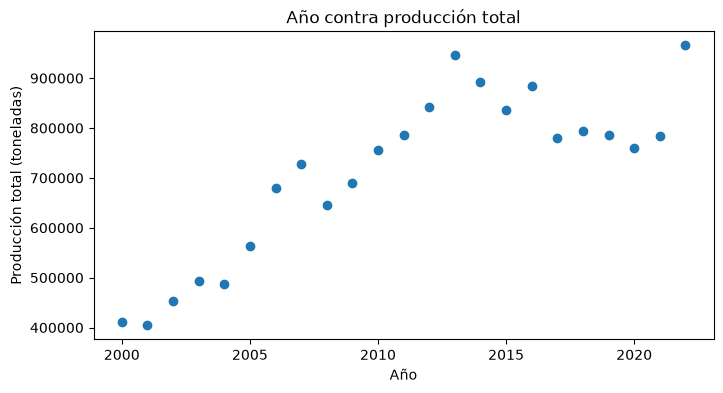

In [20]:
fig, eje = plt.subplots(figsize=(8, 4))
eje.scatter(anual["anio"], anual["total"])
eje.set_title("Año contra producción total")
eje.set_xlabel("Año")
eje.set_ylabel("Producción total (toneladas)")
plt.show()

Calculo de la fuerza de la relación entre los datos. (r = 0.84 presentando una relación fuerte cercana a 1).

In [21]:
r = np.corrcoef(anual["anio"], anual["total"])[0, 1]
print("r =", round(r, 2))

r = 0.84


Grafico mapa de calor de correlaciones

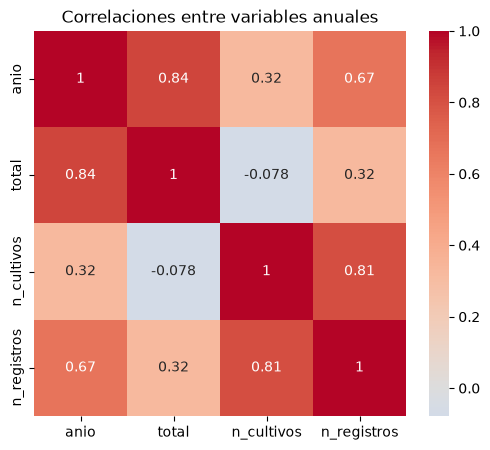

In [22]:
fig, eje = plt.subplots(figsize=(6, 5))
sns.heatmap(anual.corr(), annot=True, center=0, cmap="coolwarm", ax=eje)
eje.set_title("Correlaciones entre variables anuales")
plt.show()

 `n_registros` sube en los años recientes. Parte del aumento del total puede venir de **más datos registrados** y no de más producción real.
Que `anio` y `total` se muevan juntos no prueba que el tiempo cause la producción.

Grafica un boxplot de cada subregión, usando la producción en escala comprimida. Esto nos sirve para comparar el valor típico y la dispersión entre subregiones.

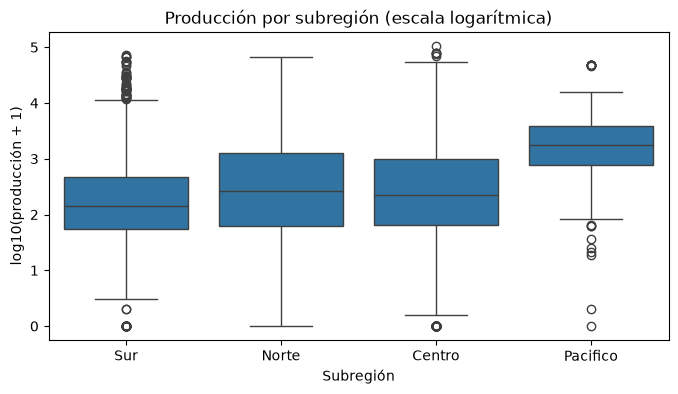

In [23]:
fig, eje = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="Subregion", y="log_prod", ax=eje)
eje.set_title("Producción por subregión (escala logarítmica)")
eje.set_xlabel("Subregión")
eje.set_ylabel("log10(producción + 1)")
plt.show()

La mediana mas alta que logramos evidenciar es la de la subregión Pacifico y la la subregión con mayor variación es Norte, el que tiene mas datos atipicos es Centro.

### 5.7 Categoría contra número: producción por ciclo (Pregunta 3)
Grafica un boxplot por ciclo, usando la producción en escala comprimida.(Anual, Semestre 1, Semestre 2).

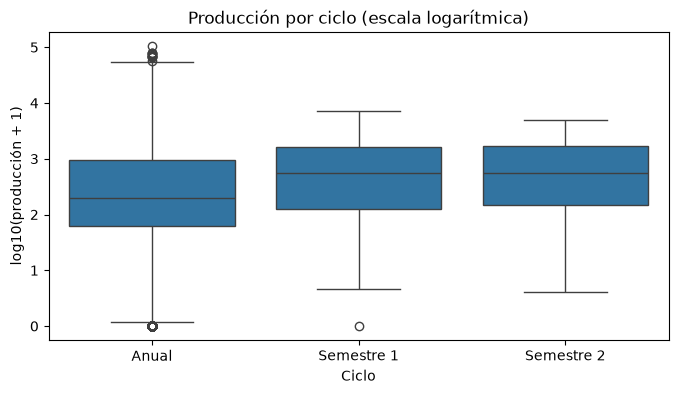

In [24]:
fig, eje = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="Ciclo", y="log_prod", ax=eje)
eje.set_title("Producción por ciclo (escala logarítmica)")
eje.set_xlabel("Ciclo")
eje.set_ylabel("log10(producción + 1)")
plt.show()

Graficar categoría contra categoría: subregión y ciclo de forma % como un grafico tipo mapa de calor.

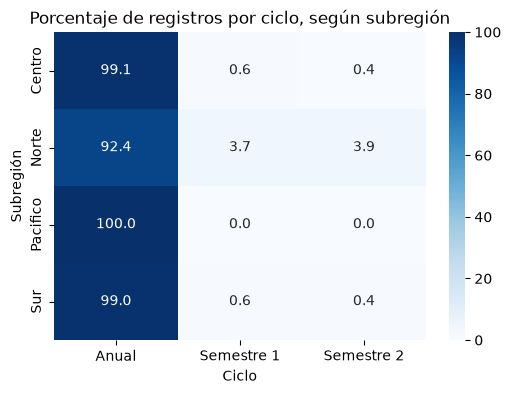

In [25]:
cruz = pd.crosstab(df["Subregion"], df["Ciclo"], normalize="index") * 100
fig, eje = plt.subplots(figsize=(6, 4))
sns.heatmap(cruz, annot=True, fmt=".1f", cmap="Blues", ax=eje)
eje.set_title("Porcentaje de registros por ciclo, según subregión")
eje.set_xlabel("Ciclo")
eje.set_ylabel("Subregión")
plt.show()

Con este grafico confirmamos parcialmente que el pacifico no cuenta con registros semestrales, el 100% de los registros son anuales, comportamiento que es similarpara las demas subregiones cuyos registros son en su mayoría Anuales.

## (`groupby`)

Se reúne las filas que comparten una característica y se calcula un resumen de cada grupo. Siempre se incluye el conteo (`count`) para saber qué tan grande es cada grupo.

Por subregión

Se agrupa por subregión calculando para cada una el número de filas, el promedio, la mediana, la desviación y el total de cada subregión.

In [26]:
df.groupby("Subregion")["produccion"].agg(["count", "mean", "median", "std", "sum"]).round(1)

,count,mean,median,std,sum
Subregion,,,,,
Centro,3301,2251.0,219.0,6874.2,7430483.9
Norte,3655,1390.5,260.0,3386.4,5082289.9
Pacifico,164,5517.9,1730.0,10831.9,904937.0
Sur,2833,1043.2,144.0,4471.0,2955404.3


Graficar la producción **total** de cada subregión en barras, de menor a mayor.

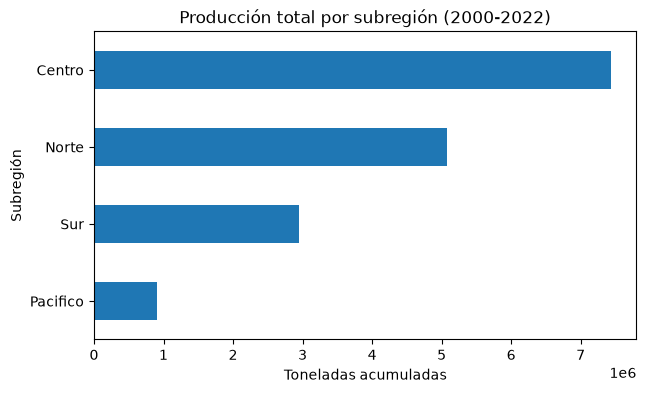

In [27]:
total_sub = df.groupby("Subregion")["produccion"].sum().sort_values()
fig, eje = plt.subplots(figsize=(7, 4))
total_sub.plot(kind="barh", ax=eje)
eje.set_title("Producción total por subregión (2000-2022)")
eje.set_xlabel("Toneladas acumuladas")
eje.set_ylabel("Subregión")
plt.show()

La subregión que mas produce en Centro; sin embargo, pacifico cuenta con pocos registros lo cual no permite identificar si realmente no produce mucho mas.

Esta vez se realiza la agrupación pero por ciclo. 

In [28]:
df.groupby("Ciclo")["produccion"].agg(["count", "mean", "median"]).round(1)

,count,mean,median
Ciclo,,,
Anual,9617,1664.7,200.0
Semestre 1,171,1122.8,555.5
Semestre 2,165,1043.4,560.0


Se genera un grafico de barras horizontal  la sumatoria de producción de cada cultivo de menor a mayor.

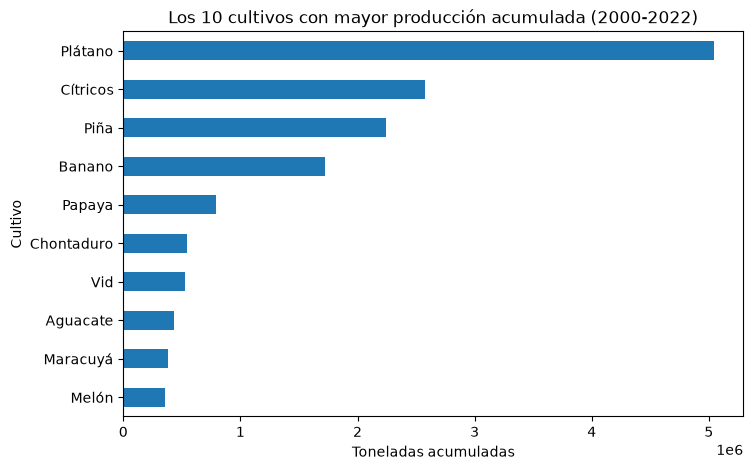

In [29]:
top = df.groupby("Cultivo")["produccion"].sum().sort_values(ascending=False).head(10)
fig, eje = plt.subplots(figsize=(8, 5))
top.sort_values().plot(kind="barh", ax=eje)
eje.set_title("Los 10 cultivos con mayor producción acumulada (2000-2022)")
eje.set_xlabel("Toneladas acumuladas")
eje.set_ylabel("Cultivo")
plt.show()

Calculo % aportado por cada uno de los 10 cultivos.

In [30]:
(top / df["produccion"].sum() * 100).round(1)

Cultivo
Plátano       30.8
Cítricos      15.7
Piña          13.7
Banano        10.5
Papaya         4.8
Chontaduro     3.3
Vid            3.2
Aguacate       2.6
Maracuyá       2.3
Melón          2.2
Name: produccion, dtype: float64

Los cultivos que lideran el % de aporte corresponden a Plátano, seguido de los cítricos, la piña y el banano.

Identificación de los municipios con mayor producción y su respectivo % Acumulado.

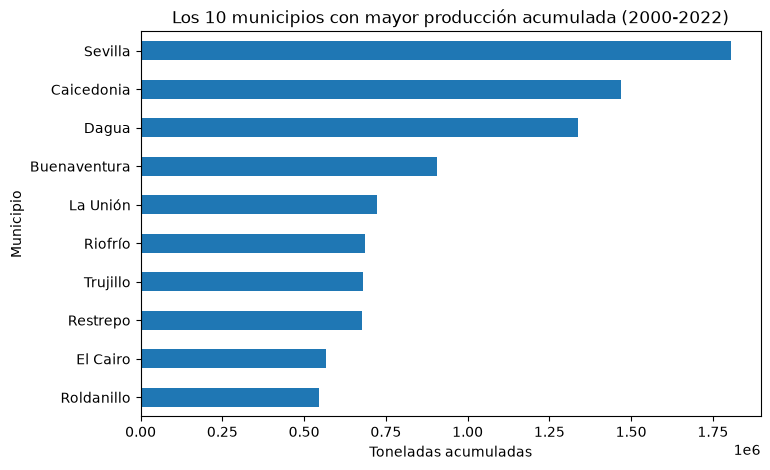

Municipios en total: 42
Los 5 primeros aportan: 38.1 % del total
Los 10 primeros aportan: 57.4 % del total


In [31]:
mun = df.groupby("Municipio")["produccion"].sum().sort_values(ascending=False)
top_mun = mun.head(10)

fig, eje = plt.subplots(figsize=(8, 5))
top_mun.sort_values().plot(kind="barh", ax=eje)
eje.set_title("Los 10 municipios con mayor producción acumulada (2000-2022)")
eje.set_xlabel("Toneladas acumuladas")
eje.set_ylabel("Municipio")
plt.show()

acumulado = mun.cumsum() / mun.sum() * 100
print("Municipios en total:", len(mun))
print("Los 5 primeros aportan:", round(acumulado.iloc[4], 1), "% del total")
print("Los 10 primeros aportan:", round(acumulado.iloc[9], 1), "% del total")

### 6.5 Cultivos que ganaron o perdieron producción (Pregunta 5)
Determinación de los cultivos que ganaron o perdieron producción, estableciendo los periodos requeridos y descartando los que se encuentran fuera del mismo.
Eliminando los cultivos que no cuentan con datos en ambos periodo y finalmente determinando el %.

**Qué hace el código de abajo**

- `np.where(condición, valor_si, valor_no)`: crea la columna `periodo`. Los años 2000 a 2004 quedan como `"2000-2004"`, los años 2018 a 2022 como `"2018-2022"` y el resto queda vacío.
- `dropna(subset=["periodo"])`: descarta los años que no están en ninguno de los dos periodos.
- `groupby(["Cultivo", "periodo"])[...].sum()`: suma la producción de cada cultivo en cada periodo.
- `.unstack()`: pone cada periodo en su propia columna.
- `.dropna()`: quita los cultivos que no tienen datos en los dos periodos.
- `cambio[cambio["2000-2004"] >= 1000]`: se queda con cultivos con al menos 1.000 toneladas al inicio, para que el porcentaje no sea engañoso.
- `cambio_pct`: calcula el cambio en porcentaje: (final - inicial) / inicial * 100.

In [32]:
df["periodo"] = np.where(df["anio"] <= 2004, "2000-2004",
                np.where(df["anio"] >= 2018, "2018-2022", None))

cambio = (
    df.dropna(subset=["periodo"])
    .groupby(["Cultivo", "periodo"])["produccion"].sum()
    .unstack()
    .dropna()
)
cambio = cambio[cambio["2000-2004"] >= 1000]
cambio["cambio_pct"] = ((cambio["2018-2022"] - cambio["2000-2004"]) / cambio["2000-2004"] * 100).round(1)
cambio = cambio.sort_values("cambio_pct")
cambio

periodo,2000-2004,2018-2022,cambio_pct
Cultivo,,,
Brevo,1010.5000,2.800000e+01,-97.2
Curuba,7339.2500,1.122820e+03,-84.7
Melón,115597.7500,2.092340e+04,-81.9
Chontaduro,54569.0000,1.110000e+04,-79.7
Tomate de Árbol,25920.3280,7.364450e+03,-71.6
Granadilla,41682.6900,1.367689e+04,-67.2
Maracuyá,91267.4420,5.866784e+04,-35.7
Bananito,12265.0000,9.451000e+03,-22.9
Coco,14971.0000,1.189100e+04,-20.6


Graficar el cambio porcentual de cada cultivo en barras horizontales.

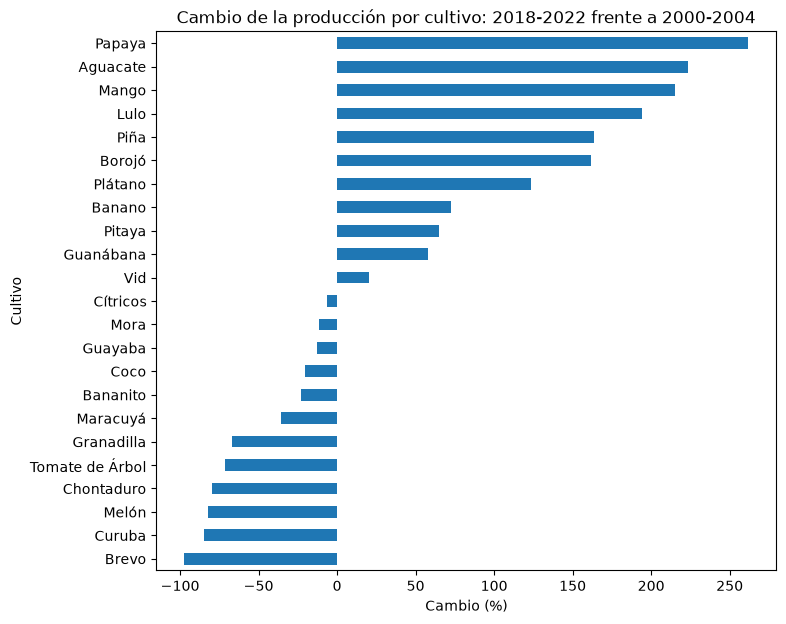

In [33]:
fig, eje = plt.subplots(figsize=(8, 7))
cambio["cambio_pct"].plot(kind="barh", ax=eje)
eje.set_title("Cambio de la producción por cultivo: 2018-2022 frente a 2000-2004")
eje.set_xlabel("Cambio (%)")
eje.set_ylabel("Cultivo")
plt.show()

Los porcentajes pueden salir enormes cuando el punto de partida es pequeño. Además, en los años recientes hay más registros, lo que puede inflar parte del aumento.

Los cultivos Papaya Aguacate, etc. presenta en su mayoría un cambio superior al 100%; Sin embargo, los citricos, la mora, etc. Presentaron una reducción.

Validar si la relación se mantiene dentro de cada grupo.

Se mira si la relación *año contra producción* se mantiene dentro de cada subregión o si cambia.

In [34]:
anual_sub = (
    df[df["Ciclo"] == "Anual"]
    .groupby(["anio", "Subregion"])["produccion"].sum()
    .reset_index()
)
for sub, grupo in anual_sub.groupby("Subregion"):
    r = grupo["anio"].corr(grupo["produccion"])
    print(sub, "-> r =", round(r, 2), "| años:", len(grupo))

Centro -> r = 0.81 | años: 23
Norte -> r = 0.71 | años: 23
Pacifico -> r = -0.19 | años: 23
Sur -> r = 0.91 | años: 23


Tres de las cuatro subregiones muestran la misma tendencia creciente que el total, así que el aumento general no es un efecto engañoso de combinar grupos. El Pacífico se comporta distinto, pero su correlación es cercana a cero y su volumen de registros es bajo, por lo que ese resultado no es concluyente así que la tendencia es real y no una ilusión estadística.

## Sección 7. Conclusiones

### Pregunta 1. ¿Ha crecido la producción total de frutales entre 2000 y 2022?

Sí, se observa un aumento. La producción total pasó de 410.278 toneladas en 2000 a 965.498 en 2022. La relación entre el año y la producción total es positiva y fuerte (r = 0,84, con 23 años). Comparando dos periodos de cinco años, la producción sumó 2,25 millones de toneladas en 2000-2004 y 4,09 millones en 2018-2022, es decir, cerca de un 82 % más.

Se debe tomar en consideración quie la cantidad de registros también subió, de 399 filas en 2000 a 536 en 2022 (r = 0,67 con el año). Parte del aumento podría deberse a que se reportan más datos. Sin embargo, entre esos dos periodos de cinco años los registros crecieron cerca de un 15 % y la producción cerca de un 82 %, por lo que el aumento no parece explicarse solo por tener más filas.

tambien apreciamos que el crecimiento no fue continuo, hubo un máximo en 2013 (947.429 toneladas), una época de estancamiento entre 2014 y 2021, y un salto en 2022. Con estos datos no se puede concluir que el paso del tiempo cause el aumento, ni explicar sus razones.

### Pregunta 2. ¿Qué cultivos y qué subregiones concentran la mayor producción?

Cuatro cultivos aportan cerca del 71 % de la producción acumulada 2000-2022: Plátano (30,8 %), Cítricos (15,7 %), Piña (13,7 %) y Banano (10,5 %). Los 10 primeros cultivos suman el 89,3 %. Por subregión, el Centro aporta el 45,4 %, el Norte el 31,0 %, el Sur el 18,1 % y el Pacífico el 5,5 %.

Adicionalmente el total acumulado depende de cuántos registros tiene cada grupo. El Pacífico tiene solo 164 registros, y eso explica en parte por qué aporta poco en total, aunque cada uno de sus registros es grande.

Estos son totales acumulados de 23 años. No dicen qué cultivo o subregión es más eficiente ni más rentable.

### Pregunta 3. ¿Cambia el comportamiento según la subregión o el ciclo?

Sí cambia. La mediana por registro es de 260 toneladas en el Norte, 219 en el Centro y 144 en el Sur. El Pacífico se sale del patrón, con una mediana de 1.730, pero tiene pocos registros. En el chequeo por subregión, la relación entre año y producción es positiva en el Centro (r = 0,81), el Norte (r = 0,71) y el Sur (r = 0,91). En el Pacífico es de −0,19. Por eso el aumento total se ve en tres de las cuatro subregiones y no hay una inversión clara de la tendencia.

Los registros semestrales tienen una mediana más alta (cerca de 555 a 560 toneladas) que los anuales (200).

Tambien los semestres son solo 336 de 9.953 registros. La diferencia entre ciclos mezcla el efecto del ciclo con el efecto del cultivo, y no se pueden separar. El resultado del Pacífico es poco confiable por tener pocos registros.

No se puede concluir que el ciclo o la subregión, por sí solos, produzcan las diferencias.

### Pregunta 4. ¿Qué municipios producen más y hay concentración?

Los cinco municipios que más producen son Sevilla (11,0 %), Caicedonia (9,0 %), Dagua (8,2 %), Buenaventura (5,5 %) y La Unión (4,4 %). Entre los cinco suman el 38,1 % de la producción, y los diez primeros suman el 57,4 %. Como hay 42 municipios, unos 10 municipios (cerca de la cuarta parte) producen más de la mitad, lo que indica una concentración moderada.

El total de un municipio depende de cuántos cultivos reporta y de cuántos años aparece en la tabla, no solo de cuánto produce.

La tabla no trae el tamaño ni el área de cada municipio, así que no se puede comparar qué municipio es más productivo en relación con su tamaño.

### Pregunta 5. ¿Qué cultivos han ganado o perdido más producción entre 2000-2004 y 2018-2022?

Se compararon 23 cultivos que tenían datos en los dos periodos y al menos 1.000 toneladas al inicio. De ellos, 11 subieron y 12 bajaron. Los mayores aumentos son Papaya (+262 %), Aguacate (+224 %), Mango (+215 %), Lulo (+194 %) y Piña (+164 %). Las mayores caídas son Brevo (−97 %), Curuba (−85 %), Melón (−82 %), Chontaduro (−80 %) y Tomate de Árbol (−72 %). En toneladas, el cambio más grande es el del Plátano: pasó de 635.870 a 1.419.648 (+123 %).

Adicionalmente un porcentaje grande puede venir de partir de una cantidad pequeña. El Mango, por ejemplo, pasó de 4.835 a 15.240 toneladas. Además, en los años recientes hay más registros en la tabla.

Estos números describen el cambio, no explican sus razones. No se puede saber con estos datos si influyeron el clima, los precios, el mercado u otras cosas.

### Conclusión general
La producción de frutales en el Valle del Cauca muestra un aumento entre 2000 y 2022, con una relación fuerte con el año (r = 0,84), que se repite en tres de las cuatro subregiones. La producción está concentrada en pocos cultivos (Plátano, Cítricos, Piña y Banano) y en pocos municipios (Sevilla, Caicedonia y Dagua a la cabeza). Aun así, no se puede afirmar por qué crece la producción, y hay cultivos importantes que cayeron.

### Limitaciones del análisis
- Hay 202 registros con producción cero, y no se sabe si significan "no se produjo" o "sin dato".
- Existen filas casi repetidas que difieren por redondeo (por ejemplo `1.139,4` contra `1.139`) y se conservaron.
- Hay más registros en los años recientes (2020-2022).
- El Pacífico tiene solo 164 registros, todos de ciclo anual.
- Los datos son totales por municipio y no traen área sembrada, así que no permiten calcular rendimiento.
